## Load data to create setup

In [4]:
dtype = {
    'date': str,  
    'line': str,
    'task': str,
    'stop_seq': 'float64',    
    'stop_name': str,
    'stop_id': str,
    'scheduled_arrival': str,  
    'scheduled_departure': str,
    'actual_arrival': str,
    'actual_departure': str,
    'detection_type': str,
    'delay': 'float64',
    'stop_desc': str,
    'stop_lat': 'float64',
    'stop_lon': 'float64', 
}

In [5]:
import pandas as pd
df = pd.read_parquet("/teamspace/studios/this_studio/huge_delays_removed_240625.parquet")

In [6]:
df = df.rename(columns={
    'Dzien': 'date',
    'Linia': 'line',
    'Zadanie': 'task',
    'Lp przystanku': 'stop_seq',
    'Przystanek nazwa': 'stop_name',
    'Przystanek numer': 'stop_id',
    'Rozkladowy czas przyjazdu': 'scheduled_arrival',
    'Rozkladowy czas odjazdu': 'scheduled_departure',
    'Rzeczywisty czas przyjazdu': 'actual_arrival',
    'Rzeczywisty czas odjazdu': 'actual_departure',
    'Rodzaj detekcji': 'detection_type',
})

df = df.astype(dtype)

In [7]:
datetime_cols = ['scheduled_arrival', 'scheduled_departure', 'date']

for col in datetime_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [8]:
df['departure_year'] = df['scheduled_departure'].dt.year
df['departure_month'] = df['scheduled_departure'].dt.month
df['departure_day'] = df['scheduled_departure'].dt.day
df['departure_decimal_hour'] = (
    df['scheduled_departure'].dt.hour +
    df['scheduled_departure'].dt.minute / 60
)

df['departure_dow'] = df['date'].dt.dayofweek

In [9]:
def assign_time_of_day(hour):
    if pd.isna(hour):
        return 'unknown'
    elif hour <= 5:
        return 'night'
    elif hour <= 11:
        return 'morning'
    elif hour <= 17:
        return 'afternoon'
    elif hour <= 21:
        return 'evening'
    else:
        return 'late_evening'

In [10]:
df['time_of_day'] = df['departure_decimal_hour'].apply(assign_time_of_day)

In [11]:
cols_to_drop = ['scheduled_arrival', 'scheduled_departure', 'actual_arrival', 'actual_departure', 'stop_desc', 'stop_lat', \
    'stop_lon', 'task', "date", "scheduled_trip_start", 'detection_type', 'Primary Key', 'stop_id']
df = df.drop(columns=cols_to_drop)


df = df.dropna(subset=['delay'])

## Preparing setup for plots

In [9]:
from pycaret.regression import RegressionExperiment
exp = RegressionExperiment()

In [10]:
split_index = int(len(df) * 0.9)

df_train = df.iloc[:split_index].copy()
df_test = df.iloc[split_index:].copy()

In [11]:
exp.setup(data = df_train, 
                target = 'delay',
                experiment_name='pycaret_lightning_ai',
                log_experiment='wandb',
                session_id=42,

                fold=3,
                n_jobs=-1,
          
                normalize = True,
                transformation = True,
                remove_multicollinearity = True,
                multicollinearity_threshold = 0.95,

                fold_strategy='timeseries',
                fold_shuffle=False,
                data_split_shuffle=False)

,Description,Value
0,Session id,42
1,Target,delay
2,Target type,Regression
3,Original data shape,"(67273425, 10)"
4,Transformed data shape,"(67273425, 14)"
5,Transformed train set shape,"(47091397, 14)"
6,Transformed test set shape,"(20182028, 14)"
7,Numeric features,6
8,Categorical features,3
9,Preprocess,True


wandb: Currently logged in as: s27478 (dsc-pjatk-warsaw) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Loading model

In [12]:
from pycaret.regression import load_model

In [13]:
model = load_model("xgboost")

Transformation Pipeline and Model Successfully Loaded


In [22]:
from pycaret.classification import get_config

config = exp.get_config('X')
config.head()

,line,stop_seq,stop_name,departure_year,departure_month,departure_day,departure_decimal_hour,departure_dow,time_of_day
0,10,1.0,Władysława IV,2023,1,1,4.183333,6,night
1,10,2.0,Nowy Port Góreckiego,2023,1,1,4.200000,6,night
2,10,3.0,Marynarki Polskiej,2023,1,1,4.233333,6,night
3,10,4.0,Śnieżna,2023,1,1,4.266667,6,night
4,10,5.0,Polsat Plus Arena Gdańsk,2023,1,1,4.300000,6,night


In [25]:
pipeline = exp.get_config('pipeline')
pipeline

Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(include=['stop_seq', 'departure_year',
                                             'departure_month', 'departure_day',
                                             'departure_decimal_hour',
                                             'departure_dow'],
                                    transformer=SimpleImputer())),
                ('categorical_imputer',
                 TransformerWrapper(include=['line', 'stop_name',
                                             'time_of_day'],
                                    transformer=SimpleImputer(...
                 TransformerWrapper(include=['line', 'stop_name'],
                                    transformer=TargetEncoder(cols=['line',
                                                                    'stop_name'],
                                                              handle_missing='return_nan'))),
                ('remove_multicollinearity',
                 TransformerWrapper(exclude=[],
                                    transformer=RemoveMulticollinearity(threshold=0.95))),
                ('transformation',
                 TransformerWrapper(transformer=PowerTransformer(standardize=False))),
                ('normalize',
                 TransformerWrapper(transformer=StandardScaler()))])

## Plots

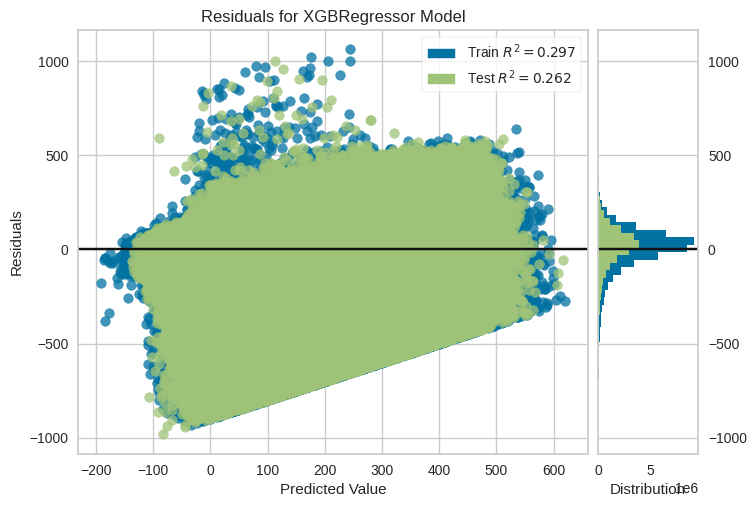

In [14]:
exp.plot_model(model, plot='residuals')    

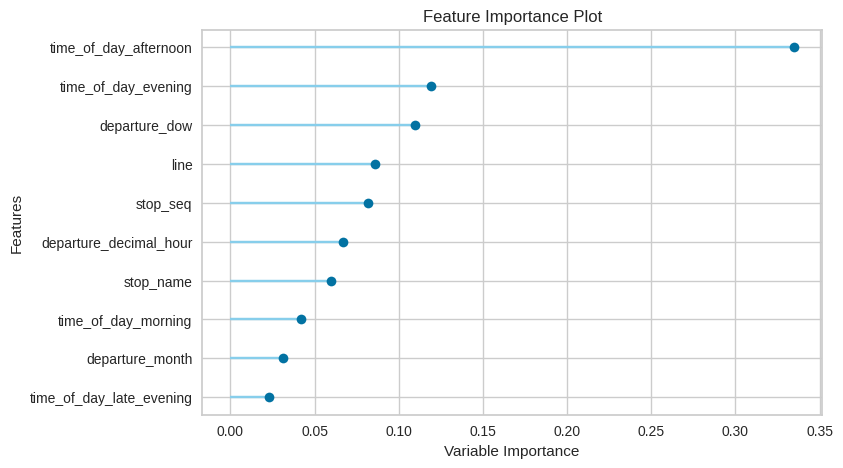

In [15]:
exp.plot_model(model, plot='feature') 

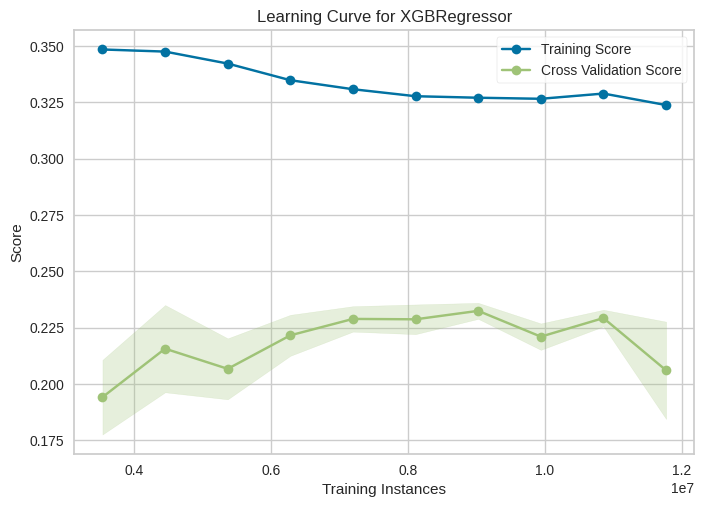

In [16]:
exp.plot_model(model, plot='learning')  

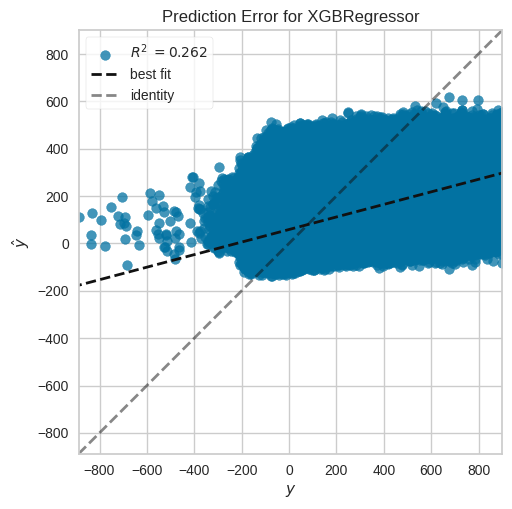

In [17]:
exp.plot_model(model, plot='error')   